In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import time
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print (tf.__version__)


2.19.0


In [107]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DELIVERABLE 1: DATA LOADING AND PREPROCESSING

LOAD CSV FILES

In [108]:
train = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_train.csv")
test = pd.read_csv("/content/drive/MyDrive/M6_assignment/sign_mnist_test.csv")

print(train.shape)
print(test.shape)

(27455, 785)
(7172, 785)


NORMALISE PIXEL VALUES TO [0, 1]

In [109]:
x_train_full = train.drop('label', axis = 1).values
y_train_full = train['label'].values

x_test = test.drop('label', axis = 1).values
y_test = test['label'].values

x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

num_classes = 25
class_names = [chr (i) for i in range (65,91) if chr(i) not in ('J', 'Z')]

CREATE A VALIDATION SPLIT FROM THE TRAINING SET

In [110]:
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full,
    test_size = 0.2, random_state = 42, stratify = y_train_full)

y_train = to_categorical(y_train, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"Train: {x_train.shape[0]} | valid: {x_valid.shape[0]} | test: {x_test.shape[0]}")
print("Classes:", class_names)

Train: 21964 | valid: 5491 | test: 7172
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


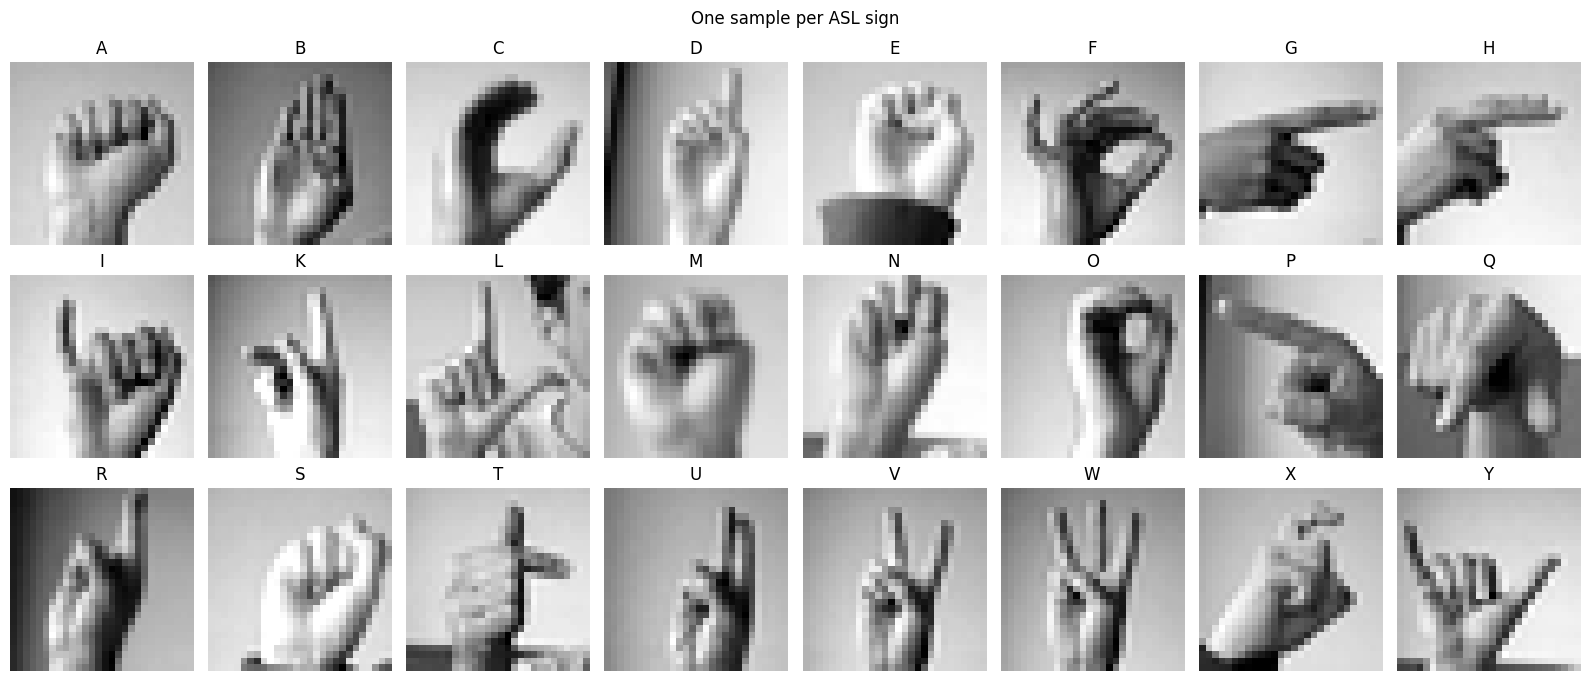

In [111]:
unique_labels = np.unique(y_train.argmax(axis = 1))

fig, axes = plt.subplots(3, 8, figsize = (16, 7))
axes = axes.flatten()

for i, class_name_char in enumerate(class_names):
  # Determine the actual numeric label value corresponding to the i-th class_name
  actual_label_value = i
  if i >= 9: # Account for the skipped 'J' (label 9)
    actual_label_value += 1

  sample = np.where(y_train.argmax(axis = 1) == actual_label_value)[0][0]
  axes[i].imshow(x_train[sample].squeeze(), cmap = 'gray')
  axes[i].set_title(class_name_char)
  axes[i].axis('off')

plt.suptitle("One sample per ASL sign")
plt.tight_layout()
plt.show()

DELIVERABLE 2: CNN ARCHITECTURES

 BASELINE CNN

In [112]:
model_baseline = models.Sequential([
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax')
])

model_baseline.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_96 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,577 (1.62 MB)

 Trainable params: 423,577 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

ENHANCED VGG-STYLE CNN

In [113]:
model_enhanced = models.Sequential([
    layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1 )),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation = 'softmax'),

])

model_enhanced.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_98 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_84          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_85          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_86          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_87          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_88          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_89          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 438,585 (1.67 MB)

 Trainable params: 437,561 (1.67 MB)

 Non-trainable params: 1,024 (4.00 KB)

DELIVERABLE 3: TRAINING, TESTING AND EVALUATION

 HYPERPARAMETER TUNING -- BASELINE CNN

In [114]:
callbacks = [
    EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

start = time.time()

history_baseline = model_baseline.fit(
    x_train, y_train,
    validation_data = (x_valid, y_valid),
    epochs = 50,
    batch_size = 256,
    callbacks = callbacks,
    verbose = 1
)

baseline_time = round(time.time() - start)
print(f"Training time: {baseline_time} seconds")

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.2207 - loss: 2.6220 - val_accuracy: 0.6696 - val_loss: 1.3801 - learning_rate: 0.0010
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5910 - loss: 1.2512 - val_accuracy: 0.8753 - val_loss: 0.5495 - learning_rate: 0.0010
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7514 - loss: 0.7495 - val_accuracy: 0.9403 - val_loss: 0.2851 - learning_rate: 0.0010
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8219 - loss: 0.5320 - val_accuracy: 0.9678 - val_loss: 0.1714 - learning_rate: 0.0010
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8701 - loss: 0.3908 - val_accuracy: 0.9882 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9044 - loss: 0.2881 - val_accuracy: 0.9962 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9227 - loss: 0.2355 - val_accuracy:

 HYPERPARAMETER TUNING -- ENHANCED CNN

In [115]:
fresh_callbacks = [
    EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

model_enhanced.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

start = time.time()
history_enhanced = model_enhanced.fit(
    x_train, y_train,
    validation_data = (x_valid, y_valid),
    epochs = 50,
    batch_size = 256,
    callbacks = fresh_callbacks,
    verbose = 1
)

enhanced_time = round(time.time() - start)
print(f"Training time: {enhanced_time} seconds")


Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - accuracy: 0.5143 - loss: 1.6181 - val_accuracy: 0.0370 - val_loss: 4.2081 - learning_rate: 0.0010
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9504 - loss: 0.1755 - val_accuracy: 0.0803 - val_loss: 5.1403 - learning_rate: 0.0010
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9922 - loss: 0.0373 - val_accuracy: 0.0667 - val_loss: 8.2096 - learning_rate: 0.0010
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9960 - loss: 0.0180 - val_accuracy: 0.1461 - val_loss: 5.2996 - learning_rate: 0.0010
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9976 - loss: 0.0120 - val_accuracy: 0.4955 - val_loss: 2.0924 - learning_rate: 0.0010
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9980 - loss: 0.0091 - val_accuracy: 0.9661 - val_loss: 0.1167 - learning_rate: 0.0010
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9978 - loss: 0.0084 - val_a

  TRAINING VS VALIDATION - ACCURACY AND LOSS COMPARISON



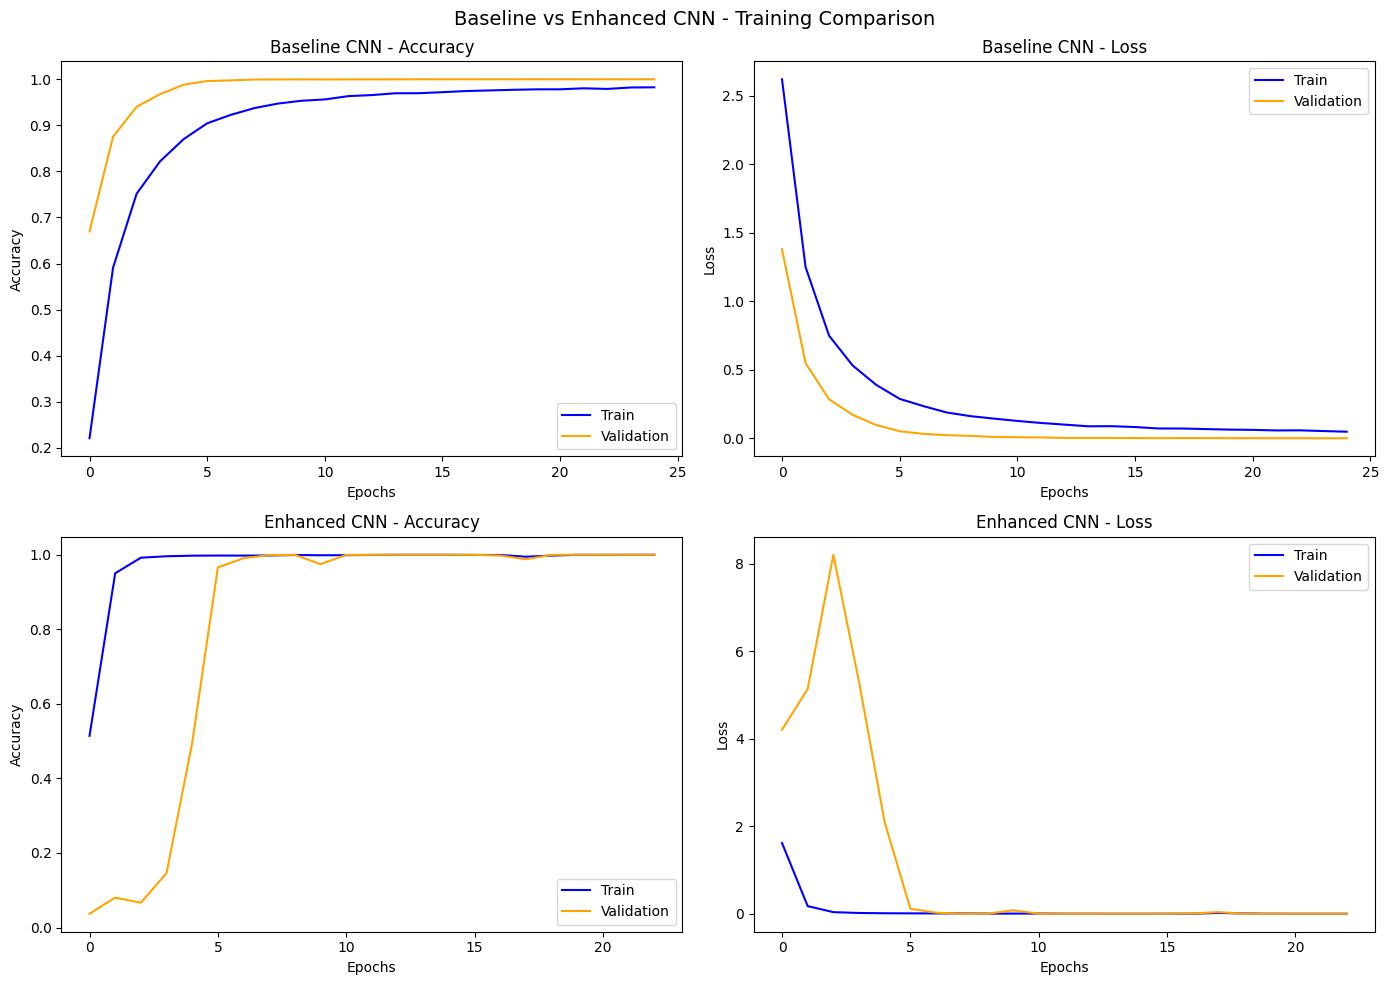

In [116]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

axes[0, 0].plot(history_baseline.history['accuracy'], label = 'Train', color = 'blue')
axes[0, 0].plot(history_baseline.history['val_accuracy'], label = 'Validation', color = 'orange')
axes[0, 0].set_title('Baseline CNN - Accuracy')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

axes[0, 1].plot(history_baseline.history['loss'], label = 'Train', color = 'blue')
axes[0, 1].plot(history_baseline.history['val_loss'], label = 'Validation', color = 'orange')
axes[0, 1].set_title('Baseline CNN - Loss')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

axes[1, 0].plot(history_enhanced.history['accuracy'], label = 'Train', color = 'blue')
axes[1, 0].plot(history_enhanced.history['val_accuracy'], label = 'Validation', color = 'orange')
axes[1, 0].set_title('Enhanced CNN - Accuracy')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()

axes[1, 1].plot(history_enhanced.history['loss'], label = 'Train', color = 'blue')
axes[1, 1].plot(history_enhanced.history['val_loss'], label = 'Validation', color = 'orange')
axes[1, 1].set_title('Enhanced CNN - Loss')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.suptitle("Baseline vs Enhanced CNN - Training Comparison", fontsize = 14)
plt.tight_layout()
plt.show()

MODEL COMPARISON - ACCURACY, LOSS, PARAMETERS AND TRAINING TIME

In [117]:
baseline_loss, baseline_accuracy = model_baseline.evaluate(x_test, y_test, verbose = 0)
enhanced_loss, enhanced_accuracy = model_enhanced.evaluate(x_test, y_test, verbose = 0)

print("Model comparision on test set")
print("==============================")
print(f"Baseline - Accuracy: {baseline_accuracy*100:.2f} | Loss: {baseline_loss:.4f}")
print(f"Enhanced - Accuracy: {enhanced_accuracy*100:.2f} | Loss: {enhanced_loss:.4f}")
print(f"Baseline - Params: {model_baseline.count_params():,}")
print(f"Enhanced - Params: {model_enhanced.count_params():,}")
print(f"Baseline - Time: {baseline_time} seconds")
print(f"Enhanced - Time: {enhanced_time} seconds")

Model comparision on test set
Baseline - Accuracy: 93.77 | Loss: 0.2064
Enhanced - Accuracy: 99.71 | Loss: 0.0084
Baseline - Params: 423,577
Enhanced - Params: 438,585
Baseline - Time: 27 seconds
Enhanced - Time: 92 seconds


3.3 CONFUSION MATRIX - BASELINE vs ENHANCED CNN

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


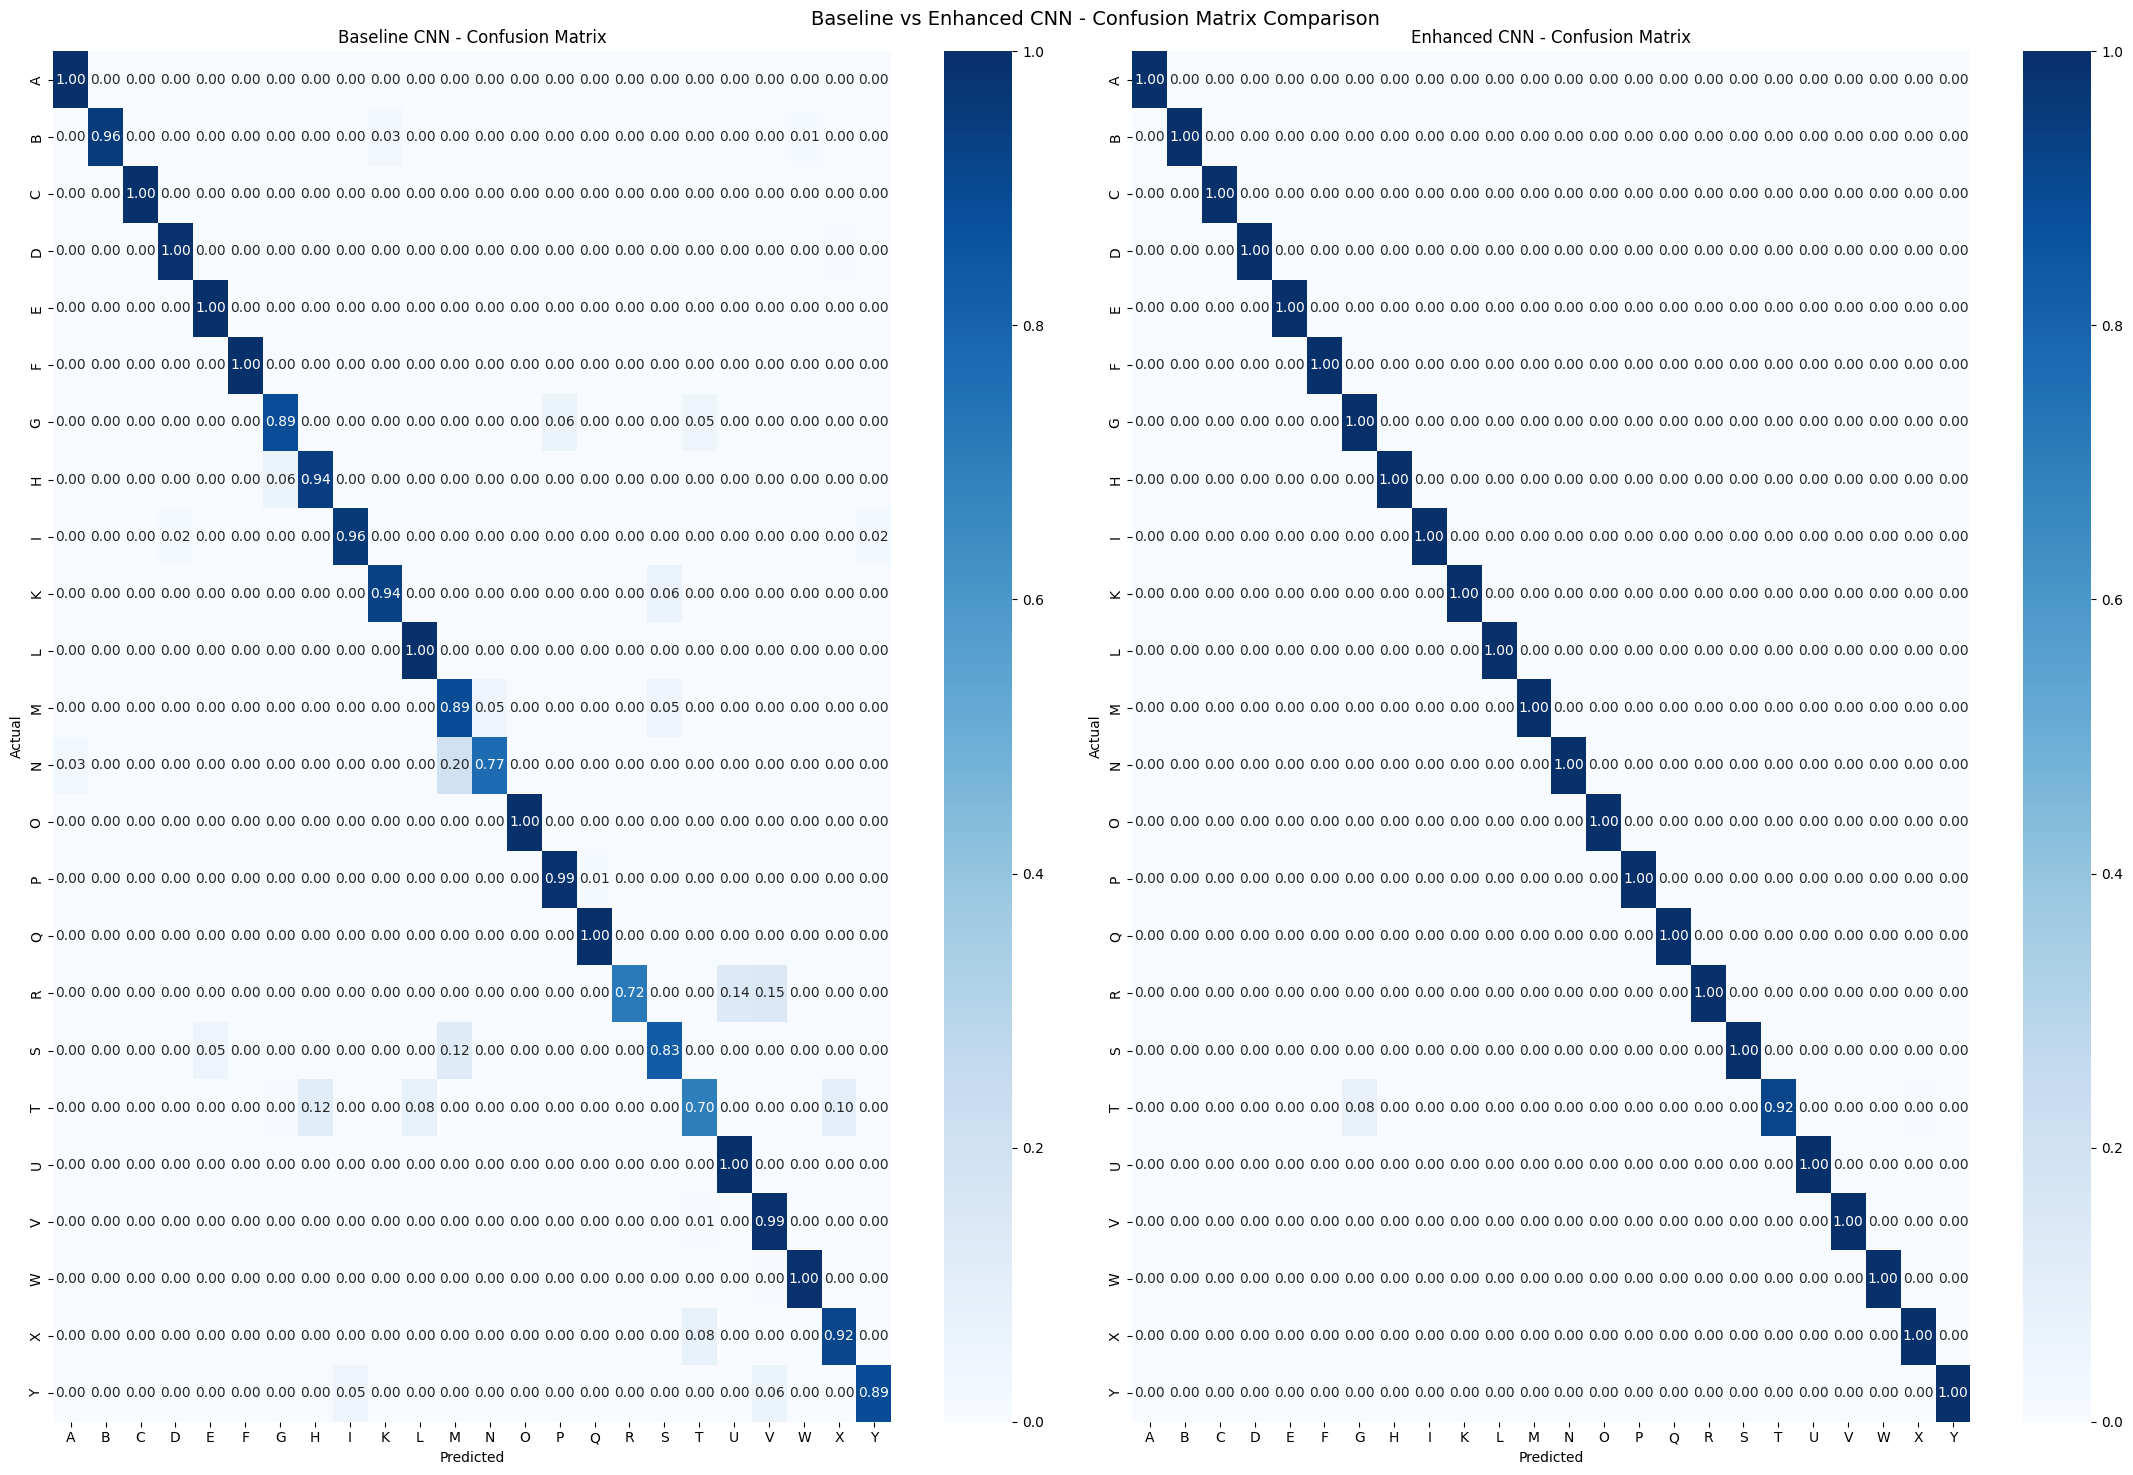

In [118]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (22, 15))

y_pred_baseline = model_baseline.predict(x_test)
y_pred_baseline_classes = np.argmax(y_pred_baseline, axis = 1)
cm_baseline = confusion_matrix(y_test_classes, y_pred_baseline_classes)
cm_baseline_normalized = cm_baseline.astype('float') / cm_baseline.sum(axis = 1)[:, np.newaxis]
sns.heatmap(cm_baseline_normalized, annot = True, fmt = '.2f', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names, ax = ax1)
ax1.set_title('Baseline CNN - Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_enhanced = confusion_matrix(y_test_classes, y_pred_classes)
cm_enhanced_normalized = cm_enhanced.astype('float') / cm_enhanced.sum(axis = 1)[:, np.newaxis]
sns.heatmap(cm_enhanced_normalized, annot = True, fmt = '.2f', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names, ax = ax2)
ax2.set_title('Enhanced CNN - Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.suptitle("Baseline vs Enhanced CNN - Confusion Matrix Comparison", fontsize = 14)
plt.tight_layout()
plt.show()

CLASSIFICATION REPORT - PRECISION, RECALL AND F1-SCORE

In [119]:
print("Classification Report - Baseline CNN")
print("="*50)
y_pred_baseline = model_baseline.predict(x_test)
y_pred_baseline_classes = np.argmax(y_pred_baseline, axis = 1)
print(classification_report(y_test_classes, y_pred_baseline_classes, target_names = class_names))

print ("Classification Report - Enhanced CNN")
print("="*50)
print(classification_report(y_test_classes, y_pred_classes, target_names = class_names))

Classification Report - Baseline CNN
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           A       0.97      1.00      0.98       331
           B       1.00      0.96      0.98       432
           C       1.00      1.00      1.00       310
           D       0.98      1.00      0.99       245
           E       0.97      1.00      0.99       498
           F       1.00      1.00      1.00       247
           G       0.93      0.89      0.91       348
           H       0.93      0.94      0.94       436
           I       0.94      0.96      0.95       288
           K       0.96      0.94      0.95       331
           L       0.91      1.00      0.95       209
           M       0.80      0.89      0.85       394
           N       0.91      0.77      0.83       291
           O       1.00      1.00      1.00       246
           P       0.95      0.99      0.97       347
           Q       0.98      1.00      0.99       164
   

SAMPLE PREDICTIONS

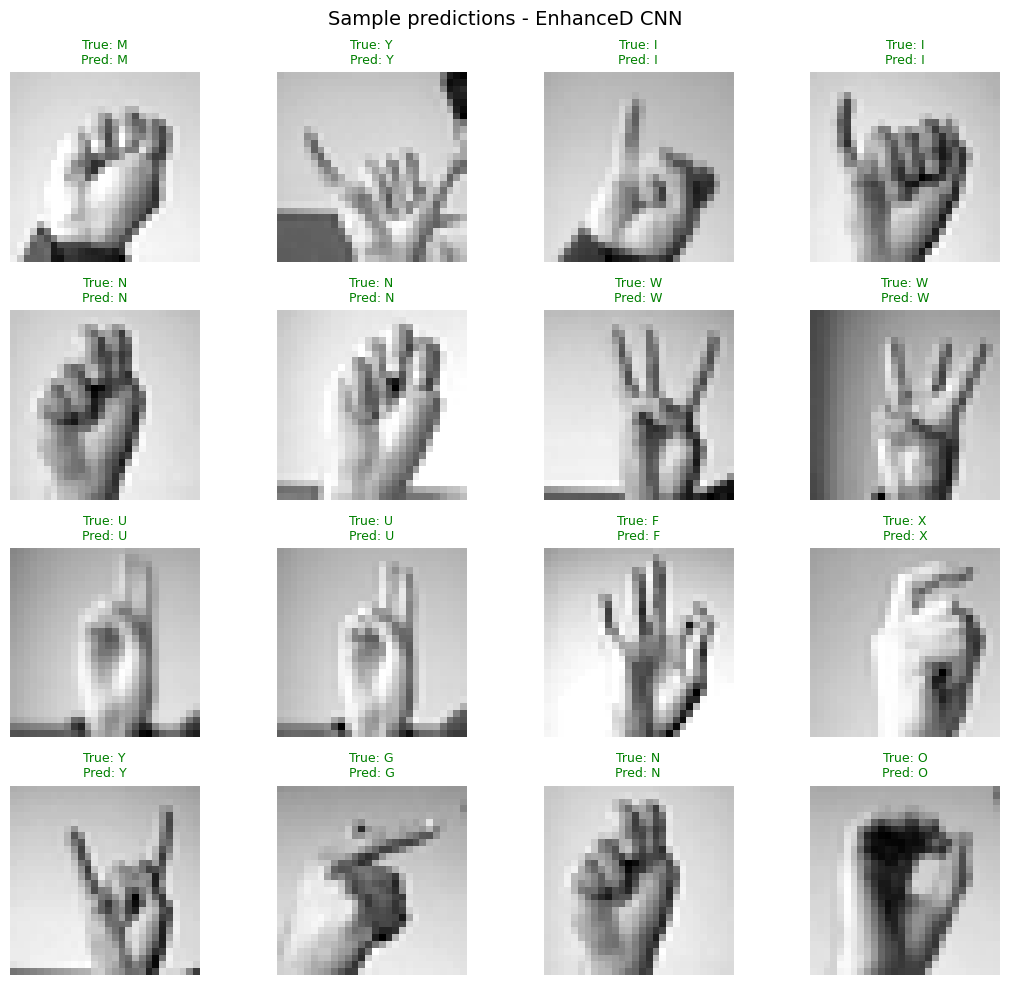

In [120]:
fig, axes = plt.subplots(4, 4, figsize = (11,10))
axes = axes.flatten()

indices = np.random.choice(len(x_test), 16, replace = False)

for i, idx in enumerate(indices):
  axes[i].imshow(x_test[idx].squeeze(), cmap = 'gray')

  true_label_numeric = y_test_classes[idx]
  pred_label_numeric = y_pred_classes[idx]
  true_label_mapped_idx = true_label_numeric

  if true_label_numeric > 8:
    true_label_mapped_idx -= 1

  pred_label_mapped_idx = pred_label_numeric
  if pred_label_numeric > 8:
    pred_label_mapped_idx -= 1

  true_label = class_names[true_label_mapped_idx]
  pred_label = class_names[pred_label_mapped_idx]

  color = 'green' if true_label == pred_label else 'red'
  axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color = color, fontsize = 9)
  axes[i].axis('off')

plt.suptitle("Sample predictions - EnhanceD CNN", fontsize = 14)
plt.tight_layout()
plt.show()